# Notebook for creating plots

In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"text.usetex": True, "font.family": "Modern"})

# Regression results analzed per class and per line

Best model: MLP, at 50 ms

Run path: julian_oelhaf/fc-fl-comparison/px1gnqw9

[Link to Panel - Error by Fault Class](https://wandb.ai/julian_oelhaf/fc-fl-comparison/runs/px1gnqw9/panel/l249k45wq?nw=nwuserjulianoelhaf)

[Link to Panel - Error by Fault Line](https://wandb.ai/julian_oelhaf/fc-fl-comparison/runs/px1gnqw9/panel/l249k45wq?nw=nwuserjulianoelhaf)

In [15]:
csv_2_path = r"C:\Users\user\Repositories\fault-classification-localization\notebooks\wandb_export_2026-03-30T17_01_47.814+02_00.csv"
csv_1_path = r"C:\Users\user\Repositories\fault-classification-localization\notebooks\wandb_export_2026-03-30T17_02_15.574+02_00.csv"

In [16]:
fl_metrics_per_fault_line = pd.read_csv(csv_1_path)
line_name_mapping = {
    "Line_1_2_a": "Line 1-2 A",
    "Line_1_2_b": "Line 1-2 B",
    "Line_2_3_a": "Line 2-3 A",
    "Line_2_3_b": "Line 2-3 B",
}
fl_metrics_per_fault_line["fault_line"] = fl_metrics_per_fault_line["fault_line"].map(
    line_name_mapping
)

fl_metrics_per_fault_line

,fault_line,mae,median_abs_error,n_samples,p90_abs_error,r2,rmse
0,Line 2-3 B,11.047377,8.599121,12042,23.849395,0.744104,14.689792
1,Line 2-3 A,10.579593,8.305458,28485,22.574558,0.769293,13.912419
2,Line 1-2 B,9.183927,6.952052,11952,20.127800,0.811071,12.410562
3,Line 1-2 A,9.083930,6.933083,28719,19.544459,0.824295,12.167294


## MAE by Fault Line - Regression Task

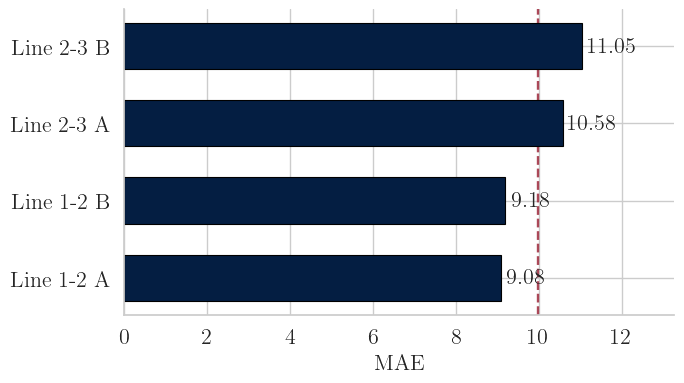

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare data ---
df = fl_metrics_per_fault_line.copy()

# Sort by MAE (ascending)
df = df.sort_values("mae", ascending=True)

lines = df["fault_line"].values
mae = df["mae"].values
p90 = df["p90_abs_error"].values

y = np.arange(len(lines))
mean_mae = mae.mean()

# --- Plot ---
# --- Plot with Z-order and Layout Tweaks ---
fig, ax = plt.subplots(figsize=(7, 4), layout="tight")

# Bars (zorder 2 sits on top of the line)
bars = ax.barh(
    y, mae, height=0.6, color="#041E42", edgecolor="black", linewidth=0.8, zorder=2
)

# Mean Line (zorder 1 sits behind bars)
ax.axvline(
    mean_mae, color="#971B2F", linestyle="--", linewidth=1.7, alpha=0.8, zorder=1
)

# Annotations & Styling
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=16, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(lines, fontsize=16, fontweight="bold")
ax.set_xlabel("MAE", fontsize=16, fontweight="bold")

# Spine and Tick cleanup
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=16, width=1.5)

ax.set_xlim(0, max(mae) * 1.2)  # Extra breathing room for the labels

# plt.tight_layout()

# Export
fig.savefig("fault_localization_mae_per_fault_line.pdf", bbox_inches="tight")

plt.show()

## MAE by Fault Class - Regression Task

In [18]:
fl_metrics_per_fault_class

,fault_line,mae,median_abs_error,n_samples,p90_abs_error,r2,rmse
0,Line_2_3_b,11.047377,8.599121,12042,23.849395,0.744104,14.689792
1,Line_2_3_a,10.579593,8.305458,28485,22.574558,0.769293,13.912419
2,Line_1_2_b,9.183927,6.952052,11952,20.127800,0.811071,12.410562
3,Line_1_2_a,9.083930,6.933083,28719,19.544459,0.824295,12.167294


In [19]:
fl_metrics_per_fault_class = pd.read_csv(csv_2_path)
fault_class_id_label_mapping = {
    "no_fault": "No Fault",
    "flt_2phg_shc_BCG": "LLG (BC)",
    "flt_2phg_shc_ABG": "LLG (AB)",
    "flt_2phg_shc_ACG": "LLG (AC)",
    "flt_3ph_shc_ABC": "LLL (ABC)",
    "flt_2ph_shc_BC": "LL (BC)",
    "flt_2ph_shc_AB": "LL (AB)",
    "flt_2ph_shc_AC": "LL (AC)",
    "flt_1phg_shc_AG": "SLG (A)",
    "flt_1phg_shc_BG": "SLG (B)",
    "flt_1phg_shc_CG": "SLG (C)",
}
fl_metrics_per_fault_class["fault_class"] = fl_metrics_per_fault_class[
    "fault_class_id_label"
].map(fault_class_id_label_mapping)
fl_metrics_per_fault_class

KeyError: 'fault_class_id_label'

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare data ---
df = fl_metrics_per_fault_class.copy()

# Sort by MAE (ascending)
df = df.sort_values("mae", ascending=True)

labels = df["fault_class"].astype(str).values
mae = df["mae"].values
p90 = df["p90_abs_error"].values

y = np.arange(len(labels))
mean_mae = mae.mean()

# --- Plot ---
# Using layout="constrained" for better handling of large fonts/labels
fig, ax = plt.subplots(figsize=(7.5, 4.5), layout="constrained")

# Bars (zorder 2)
bars = ax.barh(
    y, mae, height=0.6, color="#041E42", edgecolor="black", linewidth=0.8, zorder=2
)

# Mean MAE reference line (zorder 1)
ax.axvline(
    mean_mae, color="#971B2F", linestyle="--", linewidth=1.7, alpha=0.8, zorder=1
)

# --- Add value labels to each bar ---
ax.bar_label(bars, fmt="%.2f", padding=5, fontsize=16, fontweight="bold")

# Axis labels and Tick Styling
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=16, fontweight="bold")
ax.set_xlabel("MAE", fontsize=16, fontweight="bold")

# Clean ACM-style appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=16, width=1.5)

# Adjust x-limit to prevent label clipping
ax.set_xlim(0, max(mae) * 1.2)

# Export figure as PDF
fig.savefig("fault_localization_mae_per_fault_class.pdf", bbox_inches="tight")

plt.show()

KeyError: 'fault_class'

# Classification results analyzed per class and per line

Best model: MLP at 20 ms

Link to run: https://wandb.ai/julian_oelhaf/fc-fl-comparison/runs/a54jr3x2/panel/iie1fg8dp?nw=nwuserjulianoelhaf

## Confusion matrix - Fault Only

In [23]:
f1_confusion_matrix_fault_only_path = "wandb_export_2026-03-30T17_08_09.133+02_00.csv"
f1_confusion_matrix_fault_only = pd.read_csv(f1_confusion_matrix_fault_only_path)
# Use fault class mapping: fault_class_id_label_mapping

f1_confusion_matrix_fault_only["true"] = f1_confusion_matrix_fault_only["true"].map(
    fault_class_id_label_mapping
)
# change headers as well to use fault class names
# Convert dictionary keys to strings if necessary
str_mapping = {str(k): v for k, v in fault_class_id_label_mapping.items()}
f1_confusion_matrix_fault_only.rename(columns=str_mapping, inplace=True)

f1_confusion_matrix_fault_only

,SLG (A),SLG (B),SLG (C),LL (AB),LL (AC),LL (BC),LLG (AB),LLG (AC),LLG (BC),LLL (ABC),No Fault,true
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,No Fault
1,0.995207,0.000000,0.000000,0.000000,0.000000,0.000000,0.000436,0.000436,0.000000,0.000000,0.003922,SLG (A)
2,0.000000,0.987605,0.000000,0.000000,0.000000,0.000443,0.004427,0.000000,0.000443,0.000000,0.007083,SLG (B)
3,0.000000,0.000000,0.995182,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004818,SLG (C)
4,0.001379,0.000000,0.000000,0.990345,0.000000,0.000000,0.004138,0.000000,0.000000,0.000000,0.004138,LL (AB)
5,0.000432,0.000000,0.000000,0.000000,0.993092,0.000000,0.000000,0.003454,0.000000,0.000000,0.003022,LL (AC)
6,0.000000,0.000442,0.000000,0.000000,0.000000,0.989832,0.000000,0.000000,0.003537,0.000442,0.005747,LL (BC)
7,0.000920,0.005057,0.000000,0.005977,0.000000,0.000000,0.986207,0.000000,0.000000,0.000460,0.001379,LLG (AB)
8,0.002635,0.000000,0.002196,0.000000,0.000878,0.000000,0.000000,0.992095,0.000000,0.000878,0.001318,LLG (AC)
9,0.000000,0.002268,0.002721,0.000000,0.000000,0.002268,0.000000,0.000000,0.990930,0.000907,0.000907,LLG (BC)


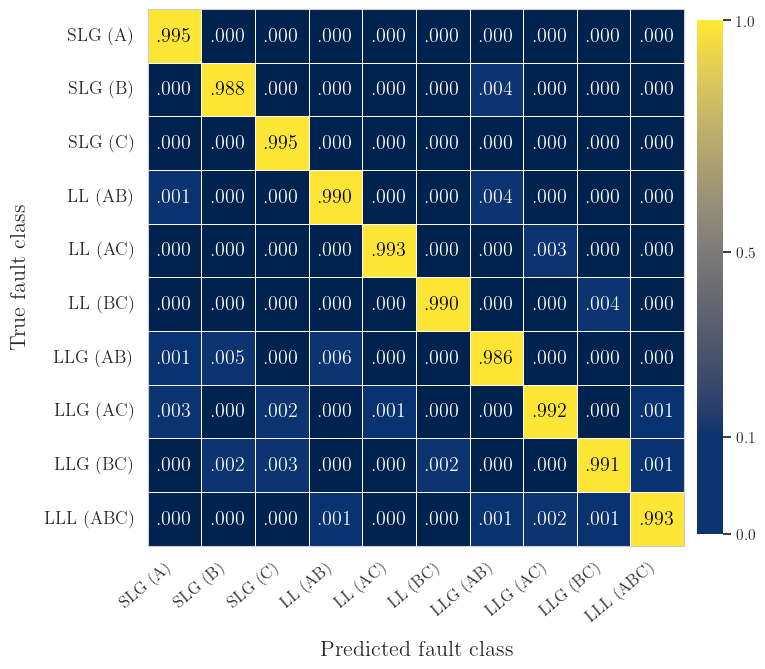

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import Normalize

# --- Prepare matrix ---
cm = f1_confusion_matrix_fault_only.copy()
cm = cm.set_index("true")
cm = cm[cm.index]
cm = cm.astype(float)

# Remove "No Fault" for a true fault-only diagnostic
if "No Fault" in cm.index:
    cm = cm.drop(index="No Fault", columns="No Fault", errors="ignore")

cm_rounded = cm.round(3)


# --- Formatting helpers ---
def trim_zeros(x, pos=None):
    s = f"{x:.3f}"
    if s.startswith("0."):
        s = s.replace("0.", ".", 1)
    if s == "1.000":
        s = "1.00"
    return s


annot_labels = np.vectorize(lambda x: trim_zeros(x))(cm_rounded.values)


class ShiftedNormalizeNonZero(Normalize):
    def __init__(self, vmin=0.0, vmax=1.0, lo=0.10, clip=False):
        self.lo = lo
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x = super().__call__(value, clip)
        return np.where(value > 0, self.lo + (1 - self.lo) * x, 0.0)


# --- Plot ---
plt.figure(figsize=(8.2, 7.2))

norm = ShiftedNormalizeNonZero(vmin=0.0, vmax=1.0, lo=0.10)

ax = sns.heatmap(
    cm_rounded,
    cmap="cividis",
    norm=norm,
    square=True,
    linewidths=0.4,
    linecolor="white",
    annot=annot_labels,
    annot_kws={"size": 14.5, "fontweight": "normal"},
    fmt="",
    cbar=True,
    cbar_kws={
        "shrink": 0.88,
        "ticks": [0.0, 0.1, 0.5, 1.0],
        "pad": 0.02,
    },
)

# --- Annotation contrast ---
threshold = 0.60
n = cm_rounded.shape[0]
for i in range(n):
    for j in range(n):
        text = ax.texts[i * n + j]
        val = cm_rounded.values[i, j]
        text.set_color("black" if val >= threshold else "white")

# --- Labels / ticks ---
ax.set_xlabel("Predicted fault class", fontsize=16, labelpad=10)
ax.set_ylabel("True fault class", fontsize=16, labelpad=10)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=40,
    ha="right",
    fontsize=12,
    fontweight="normal",
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=13,
    fontweight="normal",
)

# --- Colorbar tick label size ---
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)

# --- Outer border ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig(
    "fault_classification_confusion_matrix_fault_only.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)
plt.show()

## Confusion matrix - All Samples

In [ ]:
f1_confusion_matrix_path = "wandb_export_2026-01-23T21_42_08.747+01_00.csv"
f1_confusion_matrix = pd.read_csv(f1_confusion_matrix_path)
# Use fault class mapping: fault_class_id_label_mapping
f1_confusion_matrix["true"] = f1_confusion_matrix["true"].map(
    fault_class_id_label_mapping
)
# change headers as well to use fault class names
f1_confusion_matrix.rename(columns=str_mapping, inplace=True)
f1_confusion_matrix

,SLG (A),SLG (B),SLG (C),LL (AB),LL (AC),LL (BC),LLG (AB),LLG (AC),LLG (BC),LLL (ABC),No Fault,true
0,0.000009,0.000034,0.000009,0.000000,0.000013,0.000021,0.000000,0.000000,0.000000,0.000004,0.999910,No Fault
1,0.995207,0.000000,0.000000,0.000000,0.000000,0.000000,0.000436,0.000436,0.000000,0.000000,0.003922,SLG (A)
2,0.000000,0.987605,0.000000,0.000000,0.000000,0.000443,0.004427,0.000000,0.000443,0.000000,0.007083,SLG (B)
3,0.000000,0.000000,0.995182,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004818,SLG (C)
4,0.001379,0.000000,0.000000,0.990345,0.000000,0.000000,0.004138,0.000000,0.000000,0.000000,0.004138,LL (AB)
5,0.000432,0.000000,0.000000,0.000000,0.993092,0.000000,0.000000,0.003454,0.000000,0.000000,0.003022,LL (AC)
6,0.000000,0.000442,0.000000,0.000000,0.000000,0.989832,0.000000,0.000000,0.003537,0.000442,0.005747,LL (BC)
7,0.000920,0.005057,0.000000,0.005977,0.000000,0.000000,0.986207,0.000000,0.000000,0.000460,0.001379,LLG (AB)
8,0.002635,0.000000,0.002196,0.000000,0.000878,0.000000,0.000000,0.992095,0.000000,0.000878,0.001318,LLG (AC)
9,0.000000,0.002268,0.002721,0.000000,0.000000,0.002268,0.000000,0.000000,0.990930,0.000907,0.000907,LLG (BC)


## F1 by Fault Line | Classificaton (fault only)

In [ ]:
f1_by_fault_line_fault_only_path = "wandb_export_2026-01-23T21_43_51.505+01_00.csv"
f1_by_fault_line_fault_only = pd.read_csv(f1_by_fault_line_fault_only_path)
# Use fault line mapping: line_name_mapping
f1_by_fault_line_fault_only["fault_line"] = f1_by_fault_line_fault_only["fault_line"].map(line_name_mapping)

print(f1_by_fault_line_fault_only)

               base  fault_line  macro_f1  n_samples  weighted_f1
0  fault_start_only  Line 1-2 B  0.898689       3984     0.989552
1  fault_start_only  Line 2-3 A  0.901538       9495     0.992356
2  fault_start_only  Line 2-3 B  0.903421       4014     0.994263
3  fault_start_only  Line 1-2 A  0.903982       9573     0.994877


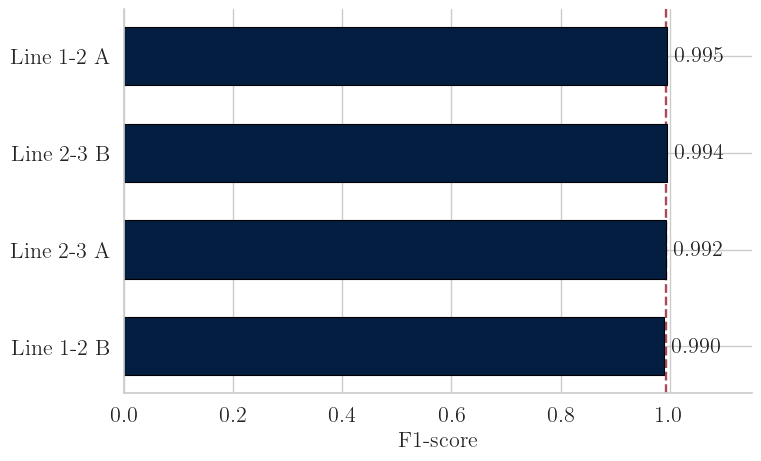

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare data ---
df = f1_by_fault_line_fault_only.copy()
df = df.dropna(subset=["weighted_f1"])
df = df.sort_values("weighted_f1", ascending=True)

lines = df["fault_line"].values
f1 = df["weighted_f1"].values
y = np.arange(len(lines))
mean_f1 = f1.mean()

# --- Plot ---
fig, ax = plt.subplots(figsize=(7.5, 4.5), layout="constrained")

# Bars (zorder 2)
bars = ax.barh(
    y, f1, height=0.6, color="#041E42", edgecolor="black", linewidth=0.8, zorder=2
)

# Mean F1 reference line (zorder 1)
ax.axvline(mean_f1, color="#971B2F", linestyle="--", linewidth=1.7, alpha=0.8, zorder=1)

# --- Add value labels to each bar ---
ax.bar_label(bars, fmt="%.3f", padding=5, fontsize=16, fontweight="bold")

# Axis Labels and Tick Styling
ax.set_yticks(y)
ax.set_yticklabels(lines, fontsize=16, fontweight="bold")
ax.set_xlabel("F1-score", fontsize=16, fontweight="bold")

# Clean ACM-style appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=16, width=1.5)

# F1 bounds (1.15 limit allows space for labels near the 1.0 mark)
ax.set_xlim(0.0, 1.15)

# Export figure as PDF
fig.savefig("fault_classification_f1_per_fault_line.pdf", bbox_inches="tight")

plt.show()

## F1 by Fault Class | Classificaton (fault only)

In [ ]:
f1_by_fault_class_path = "wandb_export_2026-01-23T21_44_27.881+01_00.csv"
f1_by_fault_class = pd.read_csv(f1_by_fault_class_path)
# Use fault class mapping: fault_class_id_label_mapping
f1_by_fault_class["fault_class"] = f1_by_fault_class["fault_label"].map(
    fault_class_id_label_mapping
)
f1_by_fault_class

,f1,fault_label,precision,recall,support,fault_class
0,0.995954,flt_3ph_shc_ABC,0.999115,0.992814,6819,LLL (ABC)
1,0.995456,flt_2ph_shc_AC,0.997831,0.993092,2316,LL (AC)
2,0.994774,flt_1phg_shc_AG,0.994340,0.995207,2295,SLG (A)
3,0.994528,flt_1phg_shc_CG,0.993876,0.995182,2283,SLG (C)
4,0.991442,flt_2phg_shc_ACG,0.990789,0.992095,2277,LLG (AC)
5,0.993566,flt_2ph_shc_BC,0.997327,0.989832,2262,LL (BC)
6,0.989796,flt_1phg_shc_BG,0.991996,0.987605,2259,SLG (B)
7,0.991829,flt_2phg_shc_BCG,0.992731,0.990930,2205,LLG (BC)
8,0.991028,flt_2ph_shc_AB,0.991713,0.990345,2175,LL (AB)
9,0.986661,flt_2phg_shc_ABG,0.987115,0.986207,2175,LLG (AB)


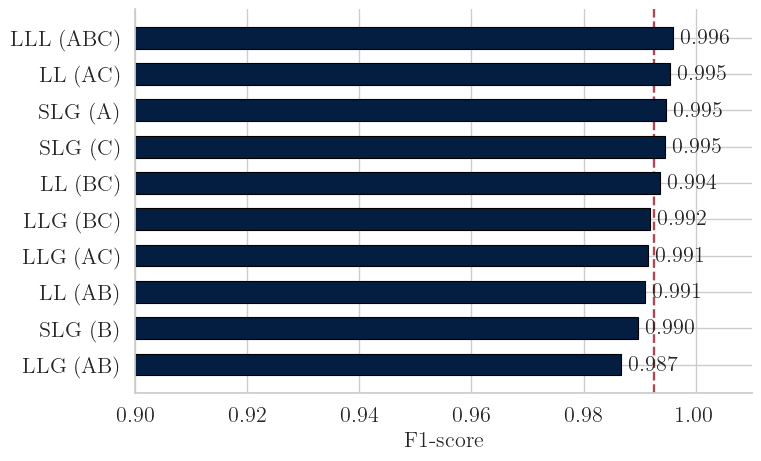

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare data ---
df = f1_by_fault_class.copy()
df = df.dropna(subset=["f1"])
df = df[df["fault_class"] != "No Fault"]
df = df.sort_values("f1", ascending=True)

classes = df["fault_class"].astype(str).values
f1 = df["f1"].values
y = np.arange(len(classes))
mean_f1 = f1.mean()

# --- Plot ---
# layout="constrained" is safer for high-resolution exports with large fonts
fig, ax = plt.subplots(figsize=(7.5, 4.5), layout="constrained")

# Bars (zorder 2 sits on top of the line)
bars = ax.barh(
    y, f1, height=0.6, color="#041E42", edgecolor="black", linewidth=0.8, zorder=2
)

# Mean F1 reference line (zorder 1 sits behind)
ax.axvline(
    mean_f1,
    color="#971B2F",
    linestyle="--",
    linewidth=1.7,
    alpha=0.8,
    zorder=1,
    label=f"Mean: {mean_f1:.2f}",
)

# --- Add value labels to each bar ---
ax.bar_label(bars, fmt="%.3f", padding=5, fontsize=16, fontweight="bold")

# Axis and Tick Styling
ax.set_yticks(y)
ax.set_yticklabels(classes, fontsize=16, fontweight="bold")
ax.set_xlabel("F1-score", fontsize=16, fontweight="bold")

# Clean ACM-style appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=16, width=1.5)

# F1 bounds with a little extra room for the labels
ax.set_xlim(0.9, 1.01)

# set 

# Export figure
fig.savefig("fault_classification_f1_per_fault_class.pdf", bbox_inches="tight")

plt.show()